# Tutorial 1: Zero Shot Learning via CLIP

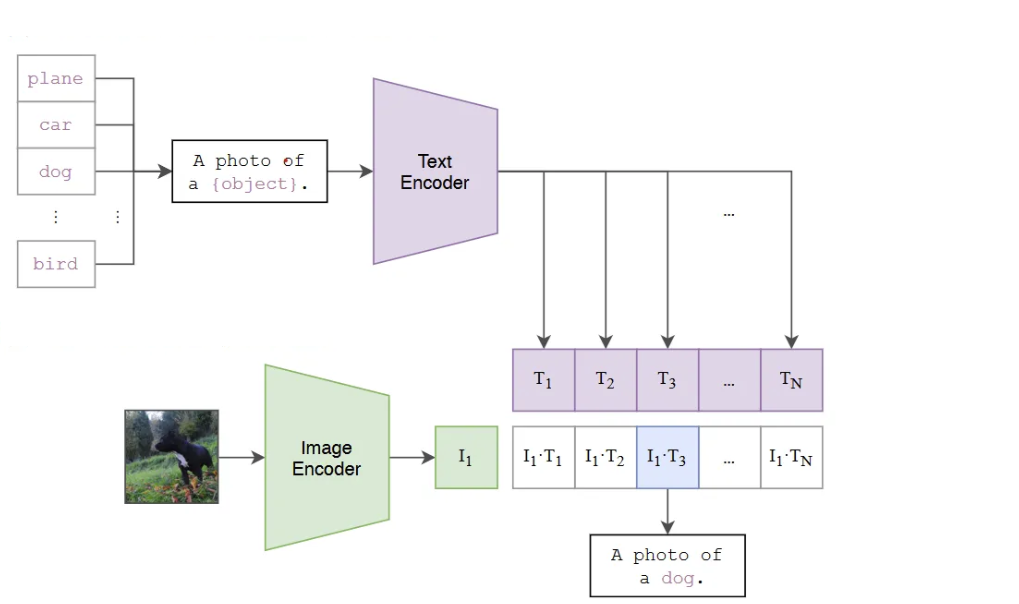

## CLIP Zero-shot Classification

In the first part of the tutorial, we will be doing zero-shot classification using the CLIP model on the intel-image dataset containing the following classes -  buildings, forests, glaciers, mountains, seas, and streets.

### Dataset

For this session we use the  [Intel Image Classification](https://www.kaggle.com/datasets/puneet6060/intel-image-classification) dataset that can be downloaded from the official website [here]({https://www.kaggle.com/datasets/puneet6060/intel-image-classification}).
The dataset contains $25000$ color images of pixels size $150\times 150$ in $6$ classes: buildings, forests, glaciers, mountains, seas, and streets. We will be using only the test set which contains $3000$ images.

### Download the dataset by running the code below

In [ ]:
! pip install opendatasets transformers --upgrade --quiet #Library for downloading datasets from Kaggle

In [ ]:
import os
import json

kaggle_username = ''
kaggle_key = ''

# Write the kaggle.json file
with open('kaggle.json', 'w') as file:
    json.dump({'username': kaggle_username, 'key': kaggle_key}, file)

import opendatasets
opendatasets.download('https://www.kaggle.com/puneet6060/intel-image-classification')

Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification


100%|██████████| 346M/346M [00:01<00:00, 335MB/s]


### Step 1: Data Transformation

Since we will be using the VIT model for image embedding, we need to apply the following transforms on our data:

1. We need to resize the image to $224\times224$.
2. We need to convert the image into a tensor (including pixel values scaling)
3. We need to normalize the pixel values with mean $(0.485, 0.456, 0.406)$ and standard deviation $(0.229, 0.224, 0.225)$.

In [ ]:
import torch
import torchvision

imagenet_transform = torchvision.transforms.Compose((
  torchvision.transforms.Resize((224,224)),
  torchvision.transforms.ToTensor(),
  torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
))

### Step 2: Dataset Loading and Transforms

We here use the [ImageFolder](https://pytorch.org/vision/main/generated/torchvision.datasets.ImageFolder.html) class from pytorch to load our training and test set respectively.

This task consists of two parts:

1. Create one dataset for the test set. Use the transform defined above.
2. Create a dataloader with a batch size of 32 for the test set.

In [ ]:
# To create datasets from folders
from torchvision.datasets import ImageFolder

#Path to your test data
test_dir = './intel-image-classification/seg_test/seg_test/'

dataset_test = ImageFolder(test_dir, imagenet_transform) # Use ImageFolder function to create your dataset

batch_size = 32

testloader = torch.utils.data.DataLoader(dataset_test, batch_size=batch_size, shuffle=True)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def show_random_images(dataloader, class_names, num_images=16):
    """
    Display random images from a given dataloader with their class labels.

    Args:
        dataloader (DataLoader): PyTorch DataLoader containing image data.
        class_names (list): List of class names corresponding to class indices.
        num_images (int): Number of images to display (default: 16).
    """

    # ImageNet normalization values (change if using different normalization)
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    # Fetch a random batch
    data_iter = iter(dataloader)
    images, labels = next(data_iter)

    # If batch size is smaller than requested images, adjust accordingly
    total_images = images.shape[0]
    num_images = min(num_images, total_images)

    # Randomly select indices from the batch
    random_indices = torch.randperm(total_images)[:num_images]

    plt.figure(figsize=(12, 8))
    grid_size = int(np.ceil(np.sqrt(num_images)))

    for idx, img_idx in enumerate(random_indices):
        plt.subplot(grid_size, grid_size, idx + 1)
        img = images[img_idx].cpu() * std + mean  # Unnormalize
        np_img = img.permute(1, 2, 0).numpy()
        np_img = np.clip(np_img, 0, 1)
        plt.imshow(np_img)
        plt.title(class_names[labels[img_idx]])
        plt.axis('off')

    plt.tight_layout()
    plt.show()

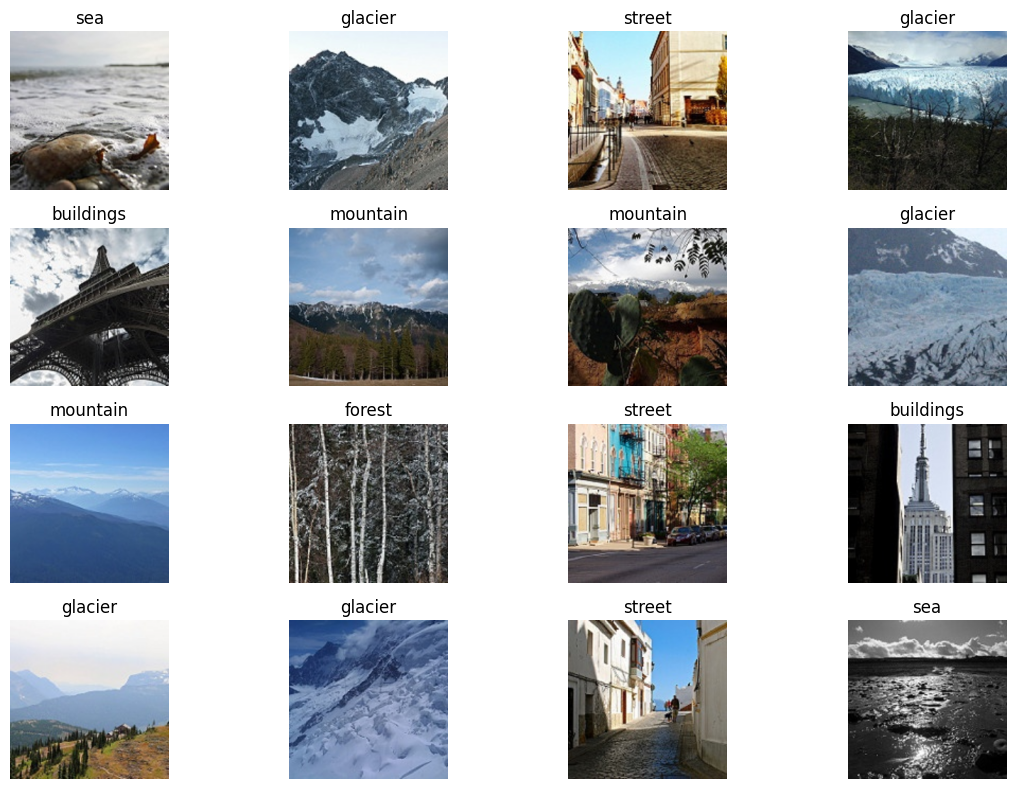

In [ ]:
show_random_images(testloader, dataset_test.classes)

### Step 3: Create Text prompts for CLIP model.

For each class in your dataset, you need to create a corresponding text prompt. These prompts can help guide the model during training and improve performance, especially in tasks like vision-language alignment.

A simple example of a prompt is:
"This is an image of a {class}."

Make sure the index of each prompt in your list matches the class index in your dataset.

Class Reference:

Index 0 - Buildings

Index 1 - Forest

Index 2 - Glacier

Index 3 - Mountain

Index 4 - Sea

Index 5 - Street

In [ ]:
text_prompts = [f"This is an image of {i}" for i in dataset_test.classes] # You can write your prompts for each class

### Step 4: Initialize CLIP model and encode your text prompts

1. Example of initialization can be found here: https://huggingface.co/docs/transformers/en/model_doc/clip
2. Documentation of CLIPProcessor: https://huggingface.co/docs/transformers/v4.41.1/en/model_doc/clip#transformers.CLIPProcessor
3. Documentation of CLIPModel: https://huggingface.co/docs/transformers/v4.41.1/en/model_doc/clip#transformers.CLIPModel
4. Documentation for other methods of CLIP: https://huggingface.co/transformers/v4.8.0/model_doc/clip.html

In [ ]:
from transformers import CLIPProcessor, CLIPModel

model_id = "openai/clip-vit-base-patch32"

# Set your device here
device = "cuda" if torch.cuda.is_available() else "cpu"

#Initializing the processor and CLIP model.
processor = CLIPProcessor.from_pretrained(model_id)
model = CLIPModel.from_pretrained(model_id)
_=model.to(device)

In [ ]:
# Create your label tokens - This will contain your input_ids of the tokens and the attention masks.
label_tokens = processor(
    text=text_prompts,
    padding=True,
    images=None,
    return_tensors='pt'
).to(device)

In [ ]:
# Encode your label tokens to get text embeddings of shape (n_labels, 512)

# To get the embeddings, call the model with the method "get_text_features". Reference: https://huggingface.co/transformers/v4.8.0/_modules/transformers/models/clip/modeling_clip.html#CLIPModel.get_text_features
label_emb = model.get_text_features(**label_tokens)

# Detach your "label_emb" from gpu
label_emb = label_emb.detach().cpu()

#Normalize your embeddings by dividing by the norm (Make sure you use the right axis)
label_emb = label_emb / label_emb.norm(dim=-1, keepdim=True)

### Step 5: Get Image embeddings and compute the labels

To classify the images via CLIP, you need to do the following steps:

1. Get image embeddings using "get_image_features" function. (The only input argument will be your image tensors). Reference: https://huggingface.co/transformers/v4.8.0/model_doc/clip.html#transformers.FlaxCLIPModel.get_image_features
2. Calculate the dot product between your image embeddings and your label embeddings
3. The label with the highest similarity will be the predicted class

In [ ]:
# To store the predicted labels and the true labels
y_pred = []
y_true = []

# Loop through your testloader here

for imgs, labels in testloader:
    # Put your imgs to device, No need to put the labels to device
    imgs = imgs.to(device)

    # Extend your list "y_true" with the labels.
    y_true.extend(labels.tolist())

    # Get image embeddings of your batch
    img_embd = model.get_image_features(imgs)

    # Detach your img_embd from cpu and convert to numpy. Your img_embd shape should be (batch_size, 512)
    img_embd = img_embd.detach().cpu()

    # Calculate the scores between img_embd and label_emb
    scores = torch.matmul(img_embd, label_emb.T)

    # Get your final prediction by taking the argmax of the scores (Make sure you use the correct axis here)
    pred = torch.argmax(scores, axis=1)

    # Extend your "y_pred" list with pred
    y_pred.extend(pred)


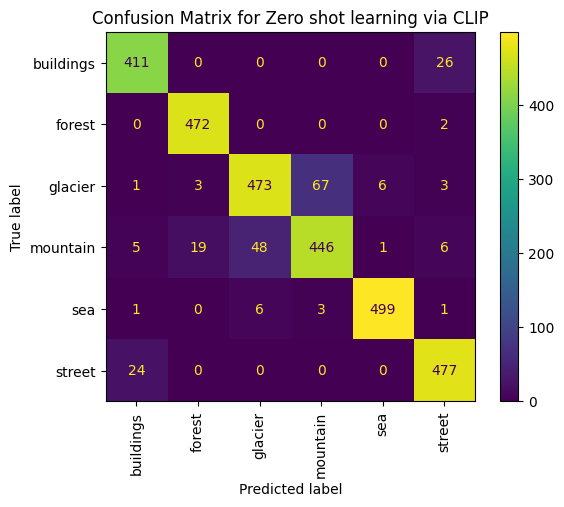

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred) # Use predictions and target from the fine-tuned network with frozen layers

plot_conf_matrix = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dataset_test.classes)
plot_conf_matrix.plot(xticks_rotation = "vertical")
plt.title('Confusion Matrix for Zero shot learning via CLIP')
plt.show()

# Tutorial 2: Automatic Image labeling (Tagging, Detection and Segmentation)

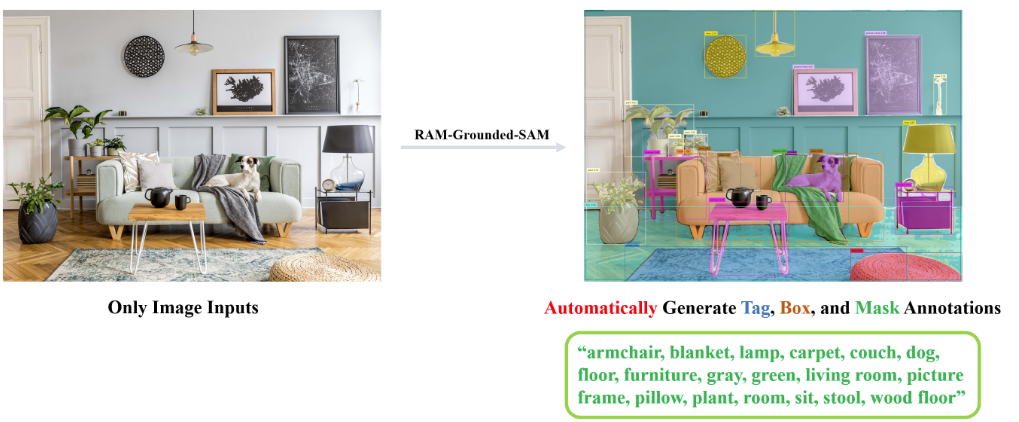

In the second tutorial, we will be using various pre-trained models to automatically annotate images (create tags, bounding boxes and segmentation masks). For this purpose, we will be using three different models namely -

1. RAM - Recognize Anything Model (Image caption generation)
2. GroundingDINO model (Zero-shot detection)
3. SAM - Segment Anything Model (Segmentation)

For this session, we will run the pipeline for only a handful of images taken from University of Oxford VGG group.

WARNING:
These models are quite large, so running them locally might exhaust your memory.
They work on Google Colab.
Also, we make use of some Linux commands (`wget` or `tar`) which might not be available on all operating systems.

#### Download the dataset

In [ ]:
!wget https://www.robots.ox.ac.uk/~vgg/data/iseg/data/images.tgz
!tar -xvf images.tgz

In [ ]:
# We will only be using the following images
images_path = ["images/sheep_2007_003593.jpg", "images/208001.jpg", "images/106024.jpg", "images/aero_2007_001884.jpg", "images/bike_2007_005878.jpg", "images/cat_2007_007530.jpg"]

#### Install the necessary libraries and download the weights of the three models

In [ ]:
# Install the packages
!pip install groundingdino-py
!pip install git+https://github.com/facebookresearch/segment-anything.git
!pip install git+https://github.com/xinyu1205/recognize-anything.git
!pip install fairscale

In [ ]:
# Download weights of each model
!wget https://github.com/IDEA-Research/GroundingDINO/releases/download/v0.1.0-alpha2/groundingdino_swinb_cogcoor.pth
!wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth
!wget https://huggingface.co/spaces/xinyu1205/recognize-anything/resolve/main/ram_swin_large_14m.pth

# Download the configuration file
!wget https://raw.githubusercontent.com/IDEA-Research/GroundingDINO/main/groundingdino/config/GroundingDINO_SwinB_cfg.py

In [ ]:
# Import the libraries
from groundingdino.models import build_model
import groundingdino.datasets.transforms as T
from groundingdino.util.inference import annotate, load_image, predict
from huggingface_hub import hf_hub_download
from groundingdino.util.slconfig import SLConfig
from groundingdino.util.utils import clean_state_dict, get_phrases_from_posmap
from segment_anything import build_sam, SamPredictor
import torch
from ram import get_transform, inference_ram
from ram.models import  ram
from PIL import Image
import numpy as np
from itertools import chain
import torchvision
import matplotlib.pyplot as plt

/usr/local/lib/python3.11/dist-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.11/dist-packages/timm/models/hub.py:4: FutureWarning: Importing from timm.models.hub is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/usr/local/lib/python3.11/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/usr/local/lib/python3.11/dist-packages/timm/models/helpers.py:7: FutureWarning: Importing from timm.models.helpers is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__

In [ ]:
# Set your device here
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


### Step 1: Initialize the three models

In [ ]:
# Initialize your caption model here (RAM - Recognize Anything Model)
model_caption = ram(pretrained="ram_swin_large_14m.pth",
                    image_size=384,
                    vit="swin_l")

# Put the model in eval mode and move it to device
model_caption.eval().to(device)

In [ ]:
# Initialize the GroundingDINO model here
args = SLConfig.fromfile("GroundingDINO_SwinB_cfg.py") #From the file that you created
args.device = device # Set the device

#Build the DINO model
model_dino = build_model(args)

#Load the weights of the model
checkpoint = torch.load("groundingdino_swinb_cogcoor.pth", map_location="cpu")
load_res = model_dino.load_state_dict(clean_state_dict(checkpoint["model"]), strict=False)
_ = model_dino.eval().to(device)

In [ ]:
# Initialize
sam_checkpoint = 'sam_vit_h_4b8939.pth'
sam = build_sam(checkpoint=sam_checkpoint)
sam.to(device=device)
sam_predictor = SamPredictor(sam)

### Step 2: Make some helper functions for the pipeline

In [ ]:
# Helper functions

def load_image(image_path):
    # load image
    image_pil = Image.open(image_path).convert("RGB")  # load image

    transform = T.Compose(
        [
            T.RandomResize([800], max_size=1333),
            T.ToTensor(),
            T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ]
    )
    image, _ = transform(image_pil, None)  # 3, h, w
    return image_pil, image

# Visualization
def show_mask(mask, ax, random_color=False):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([30/255, 144/255, 255/255, 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)


def show_box(box, ax, label):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='green', facecolor=(0,0,0,0), lw=2))
    ax.text(x0, y0, label)


# GroundingDINO bbox cleaning
def get_grounding_output(model, image, caption, box_threshold, text_threshold,device="cpu"):
    caption = caption.lower()
    caption = caption.strip()
    if not caption.endswith("."):
        caption = caption + "."
    model = model.to(device)
    image = image.to(device)
    with torch.no_grad():
        outputs = model(image[None], captions=[caption])
    logits = outputs["pred_logits"].cpu().sigmoid()[0]  # (nq, 256)
    boxes = outputs["pred_boxes"].cpu()[0]  # (nq, 4)
    logits.shape[0]

    # filter output
    logits_filt = logits.clone()
    boxes_filt = boxes.clone()
    filt_mask = logits_filt.max(dim=1)[0] > box_threshold
    logits_filt = logits_filt[filt_mask]  # num_filt, 256
    boxes_filt = boxes_filt[filt_mask]  # num_filt, 4
    logits_filt.shape[0]

    # get phrase
    tokenlizer = model.tokenizer
    tokenized = tokenlizer(caption)
    # build pred
    pred_phrases = []
    scores = []
    for logit, box in zip(logits_filt, boxes_filt):
        pred_phrase = get_phrases_from_posmap(logit > text_threshold, tokenized, tokenlizer)
        pred_phrases.append(pred_phrase + f"({str(logit.max().item())[:4]})")
        scores.append(logit.max().item())

    return boxes_filt, torch.Tensor(scores), pred_phrases

### Step 3: Run the pipeline to create the labels, bbox and segmented masks

Before NMS: 6 boxes
After NMS: 3 boxes
Before NMS: 3 boxes
After NMS: 2 boxes
Before NMS: 5 boxes
After NMS: 4 boxes
Before NMS: 5 boxes
After NMS: 3 boxes
Before NMS: 5 boxes
After NMS: 4 boxes
Before NMS: 11 boxes
After NMS: 7 boxes


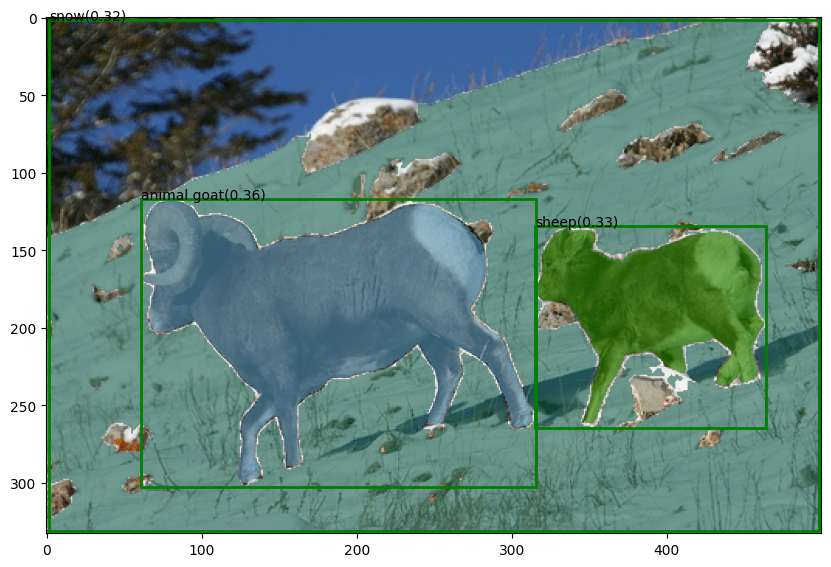

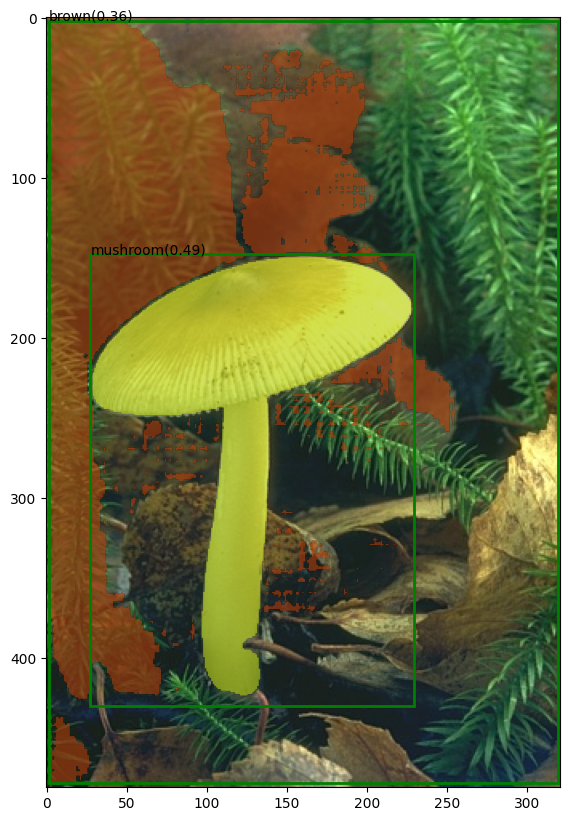

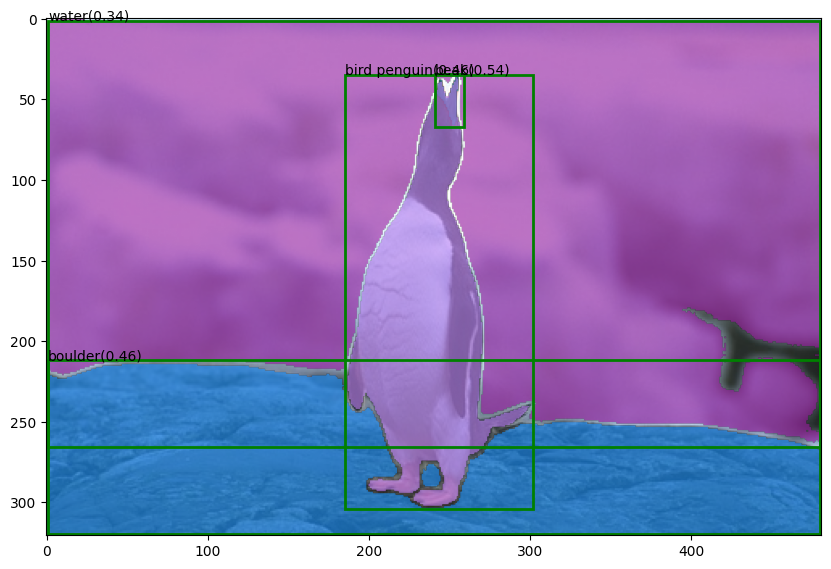

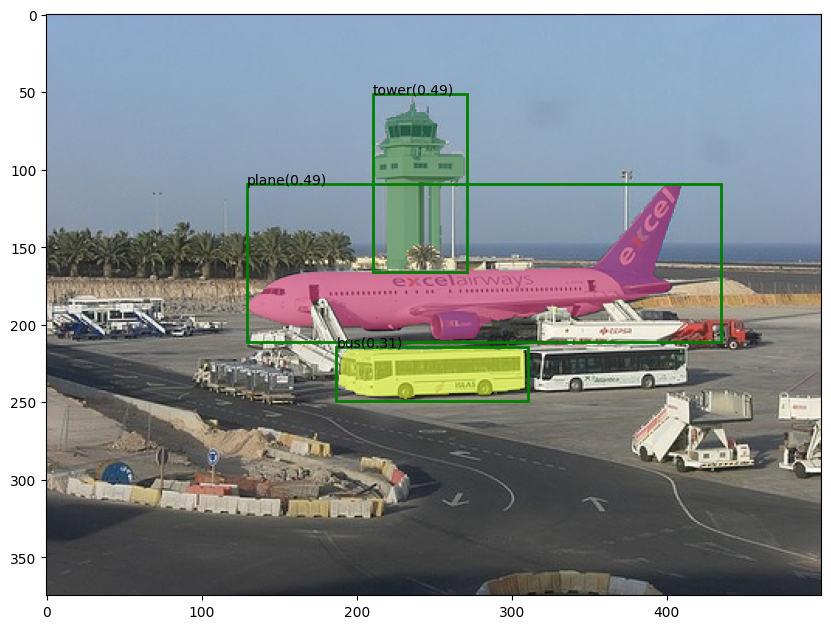

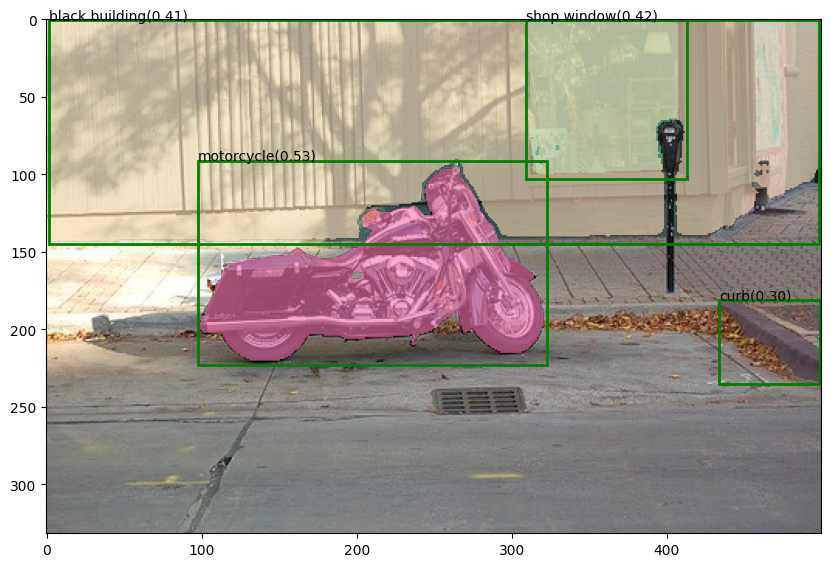

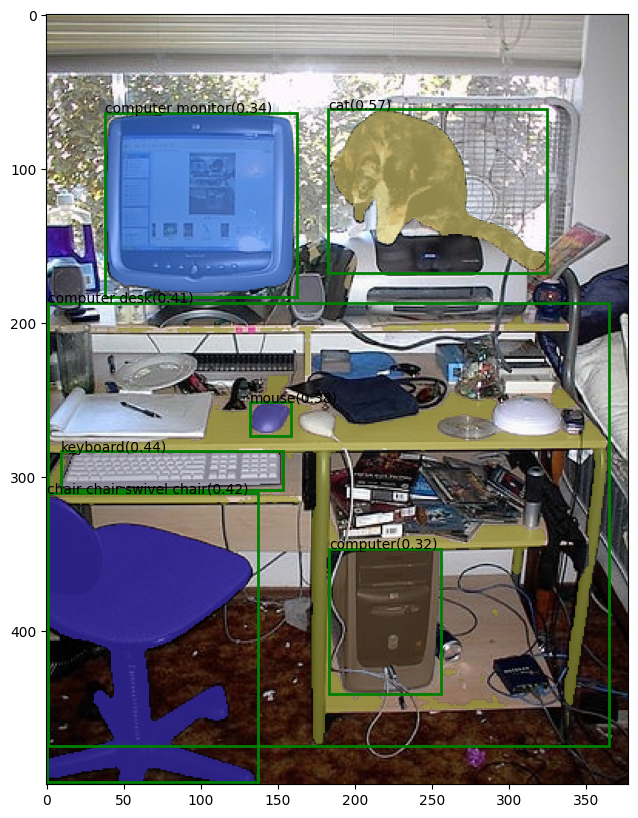

In [ ]:
# BBOX configuration
BOX_TRESHOLD = 0.3
TEXT_TRESHOLD = 0.25
iou_threshold = 0.4

#Loop through the images_path
for image_path in images_path:
    # Step 1: Get the pil image and the image tensor using the "load_image" function defined above
    image_pil, image = load_image(image_path)

    # Step 2: Get Tags using the RAM model
    transform = get_transform(image_size=384) # RAM model transforms

    # It takes image_pil as input. You need to add a dummy dimension at the first index for the batch dimension and move the image to device
    raw_image  = transform(image_pil).unsqueeze(0).to(device)

    res = inference_ram(raw_image, model_caption) # This gives the tags (English at index 0 and Chinese at index 1)

    #Access the english tags and replace "|" with ","
    tags = res[0].replace("|", ",")

    #Step 3: Run GroundingDINO model

    #Get GroundingDINO outputs
    boxes_filt, scores, pred_phrases = get_grounding_output(
        model_dino, image, tags, BOX_TRESHOLD, TEXT_TRESHOLD, device=device
    )

    size = image_pil.size
    H, W = size[1], size[0]
    for i in range(boxes_filt.size(0)):
        boxes_filt[i] = boxes_filt[i] * torch.Tensor([W, H, W, H])
        boxes_filt[i][:2] -= boxes_filt[i][2:] / 2
        boxes_filt[i][2:] += boxes_filt[i][:2]

    boxes_filt = boxes_filt.cpu()
    # use NMS to handle overlapped boxes
    print(f"Before NMS: {boxes_filt.shape[0]} boxes")
    nms_idx = torchvision.ops.nms(boxes_filt, scores, iou_threshold).numpy().tolist()
    boxes_filt = boxes_filt[nms_idx]
    pred_phrases = [pred_phrases[idx] for idx in nms_idx]
    print(f"After NMS: {boxes_filt.shape[0]} boxes")

    image_sam = np.array(image_pil)
    sam_predictor.set_image(image_sam)

    transformed_boxes = sam_predictor.transform.apply_boxes_torch(boxes_filt, image_sam.shape[:2]).to(device)

    masks, _, _ = sam_predictor.predict_torch(
        point_coords = None,
        point_labels = None,
        boxes = transformed_boxes,
        multimask_output = False,
    )

    # draw output image
    plt.figure(figsize=(10, 10))
    plt.imshow(image_sam)

    for mask in masks:
        show_mask(mask.cpu().numpy(), plt.gca(), random_color=True)

    for box, label in zip(boxes_filt, pred_phrases):
        show_box(box.numpy(), plt.gca(), label)
